# Principal Component Analysis(PCA)
This notebook implemenst PCA from scratch using Numpy, it covers the mathematical understanding of PCA and we also compare it with non-linear dimensionality reduction techniques

In [1]:
import numpy as np
import matplotlib.pyplot as plt


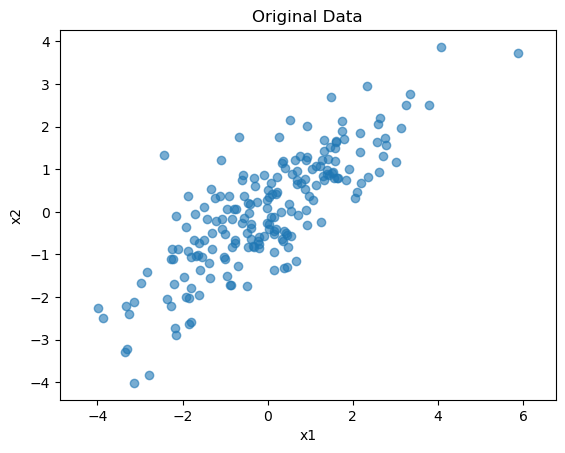

In [2]:
np.random.seed(42)

mean = [0, 0]
cov = [[3, 2],
       [2, 2]]

X = np.random.multivariate_normal(mean, cov, 200)

plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title("Original Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()

### Center towards mean

In [3]:
# center the data
X_mean = np.mean(X,axis=0)
X_center = X - X_mean

print("X_mean: ",X_mean)
print("Mean after centering ",np.mean(X_center,axis=0))

X_mean:  [-0.02646928  0.01189059]
Mean after centering  [-2.19269047e-17  6.32827124e-17]


### Calculate Covariance Matrix

In [5]:
cov_matrix = np.cov(X_center.T)
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[2.7186379  1.84079041]
 [1.84079041 1.87427921]]


In [7]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Eigenvalues:
 [4.18504129 0.40787583]

Eigenvectors:
 [[ 0.78215821 -0.62307987]
 [ 0.62307987  0.78215821]]


In [8]:
sorted_idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("Sorted Eigenvalues:\n", eigenvalues)
print("\nSorted Eigenvectors:\n", eigenvectors)

Sorted Eigenvalues:
 [4.18504129 0.40787583]

Sorted Eigenvectors:
 [[ 0.78215821 -0.62307987]
 [ 0.62307987  0.78215821]]


In [9]:
k = 1
principal_components = eigenvectors[:, :k]

print("Top Principal Component:\n", principal_components)

Top Principal Component:
 [[0.78215821]
 [0.62307987]]


### Project into 1D

In [11]:
X_pca = X_center @ principal_components

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (200, 2)
Reduced shape: (200, 1)


### Visualize

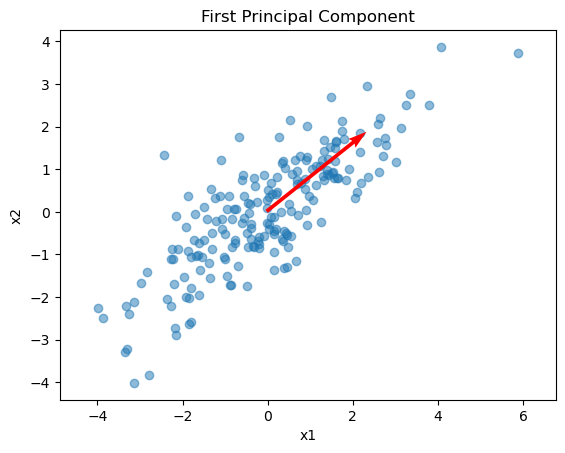

In [12]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)

origin = X_mean
pc1 = eigenvectors[:, 0] * 3

plt.quiver(origin[0], origin[1], pc1[0], pc1[1],
           angles='xy', scale_units='xy', scale=1, color='red')

plt.title("First Principal Component")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()